# Introduction to Data Science – Homework 8
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

Due: Friday, April 10 2026, 11:59pm.

In this homework, you will use clustering, principal component analysis, regular expressions, and natural language processing. 

## Your Data
First Name: Ibrahim
<br>
Last Name:  Ergin
<br>
E-mail: u1564808@umail.utah.edu
<br>
UID:    u1564808
<br>

In [1]:
# imports and setup 
import os
os.environ['OMP_NUM_THREADS'] = '1' # Set the number of threads to 1 to avoid warning about too many threads

import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn import tree, svm, metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, KFold
from sklearn.datasets import load_digits
from sklearn.preprocessing import scale
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA 

import nltk
from nltk.corpus import stopwords

import re

import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 10)
plt.style.use('ggplot')

## Part 1: Analyze Utah restaurant cuisine types

We'll analyze a dataset describing prevalence of restaurant cuisine types in the 29 counties of Utah. Theses are subsetted/cleaned from the [Open Source Places](https://gis.utah.gov/blog/2022-03-21-introducing-open-source-places/) dataset provided by the [Utah Geospatial Resource Center](https://gis.utah.gov/)

Our goal will be to use unsupervised methods to understand how prevalence of these cuisine types differs between counties. 

### Data

The data is in`county_cuisine.csv`, which contains the number of restaurants with a given cuisine within 28 of Utah's 29 counties. [Daggett County](https://en.wikipedia.org/wiki/Daggett_County,_Utah) is missing from this dataset, partially because its population size is so small. For this dataset only the top 10 different types of cuisine were included (the top 10 was computed as the 10 most prevalent statewide). 
 

### Task 1.1 Import the data and normalize restaurant counts by county population

Use the *read_csv* pandas function to import the dataset above as a dataframe. The index of the dataframe is the name of the county.

After the county name column, the next 10 columns are the top 10 cuisine types. The last column is the total population of the county.

Normalize the restaurant counts by county population to get a better understanding of restaurant density in relation to the number of people living in each county. This can help identify areas with high or low restaurant availability relative to their population size.

**Convert your final data so that it is number of restaurants per 1000 county residents.** In the end you should have a 28-by-10 dataframe whose entries are floats.

In [2]:
df = pd.read_csv('county_cuisine.csv', index_col='county')
df.head()

,american,asian,burger,chinese,indian,italian,mexican,pizza,sushi,thai,population_2024_est
county,,,,,,,,,,,
BEAVER,5,0,0,0,0,0,3,1,0,0,7339
BOX ELDER,5,0,1,3,0,0,4,2,1,0,61755
CACHE,6,1,0,3,2,2,12,14,2,1,143483
CARBON,5,0,0,0,0,1,0,1,0,0,20442
DAVIS,11,9,6,6,6,2,21,17,3,6,378572


In [3]:
cuisine_cols = df.columns[:-1] # last column is 'population_2024_est'


# Normalize the cuisine columns by population
df_norm = df[cuisine_cols].div(df['population_2024_est'], axis=0) * 1000 # per 1000 people

print(df_norm.shape)

df_norm.head()

(28, 10)


,american,asian,burger,chinese,indian,italian,mexican,pizza,sushi,thai
county,,,,,,,,,,
BEAVER,0.681292,0.000000,0.000000,0.000000,0.000000,0.000000,0.408775,0.136258,0.000000,0.000000
BOX ELDER,0.080965,0.000000,0.016193,0.048579,0.000000,0.000000,0.064772,0.032386,0.016193,0.000000
CACHE,0.041817,0.006969,0.000000,0.020908,0.013939,0.013939,0.083634,0.097573,0.013939,0.006969
CARBON,0.244594,0.000000,0.000000,0.000000,0.000000,0.048919,0.000000,0.048919,0.000000,0.000000
DAVIS,0.029057,0.023774,0.015849,0.015849,0.015849,0.005283,0.055472,0.044906,0.007925,0.015849


### Task 1.2 Perform some preliminary exploratory analysis. 

Plot a scatterplot matrix of the data. 
- Explore basic statistics of the data. 
- Describe how the variables are correlated. 

In [4]:
# statistical summary of the normalized data
df_norm.describe()

,american,asian,burger,chinese,indian,italian,mexican,pizza,sushi,thai
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,0.236506,0.006038,0.031817,0.020302,0.010785,0.020927,0.150078,0.130894,0.010163,0.016895
std,0.321718,0.012962,0.054742,0.022874,0.021407,0.035443,0.170694,0.186480,0.025479,0.040019
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.043593,0.000000,0.000000,0.000000,0.000000,0.000000,0.063253,0.040113,0.000000,0.000000
50%,0.081016,0.000000,0.009793,0.015929,0.000000,0.002642,0.094440,0.071444,0.000000,0.000000
75%,0.298077,0.001742,0.031625,0.034007,0.012647,0.028800,0.175802,0.123735,0.007508,0.015008
max,1.426025,0.046185,0.201755,0.076243,0.101031,0.161648,0.786473,0.713012,0.101031,0.202061


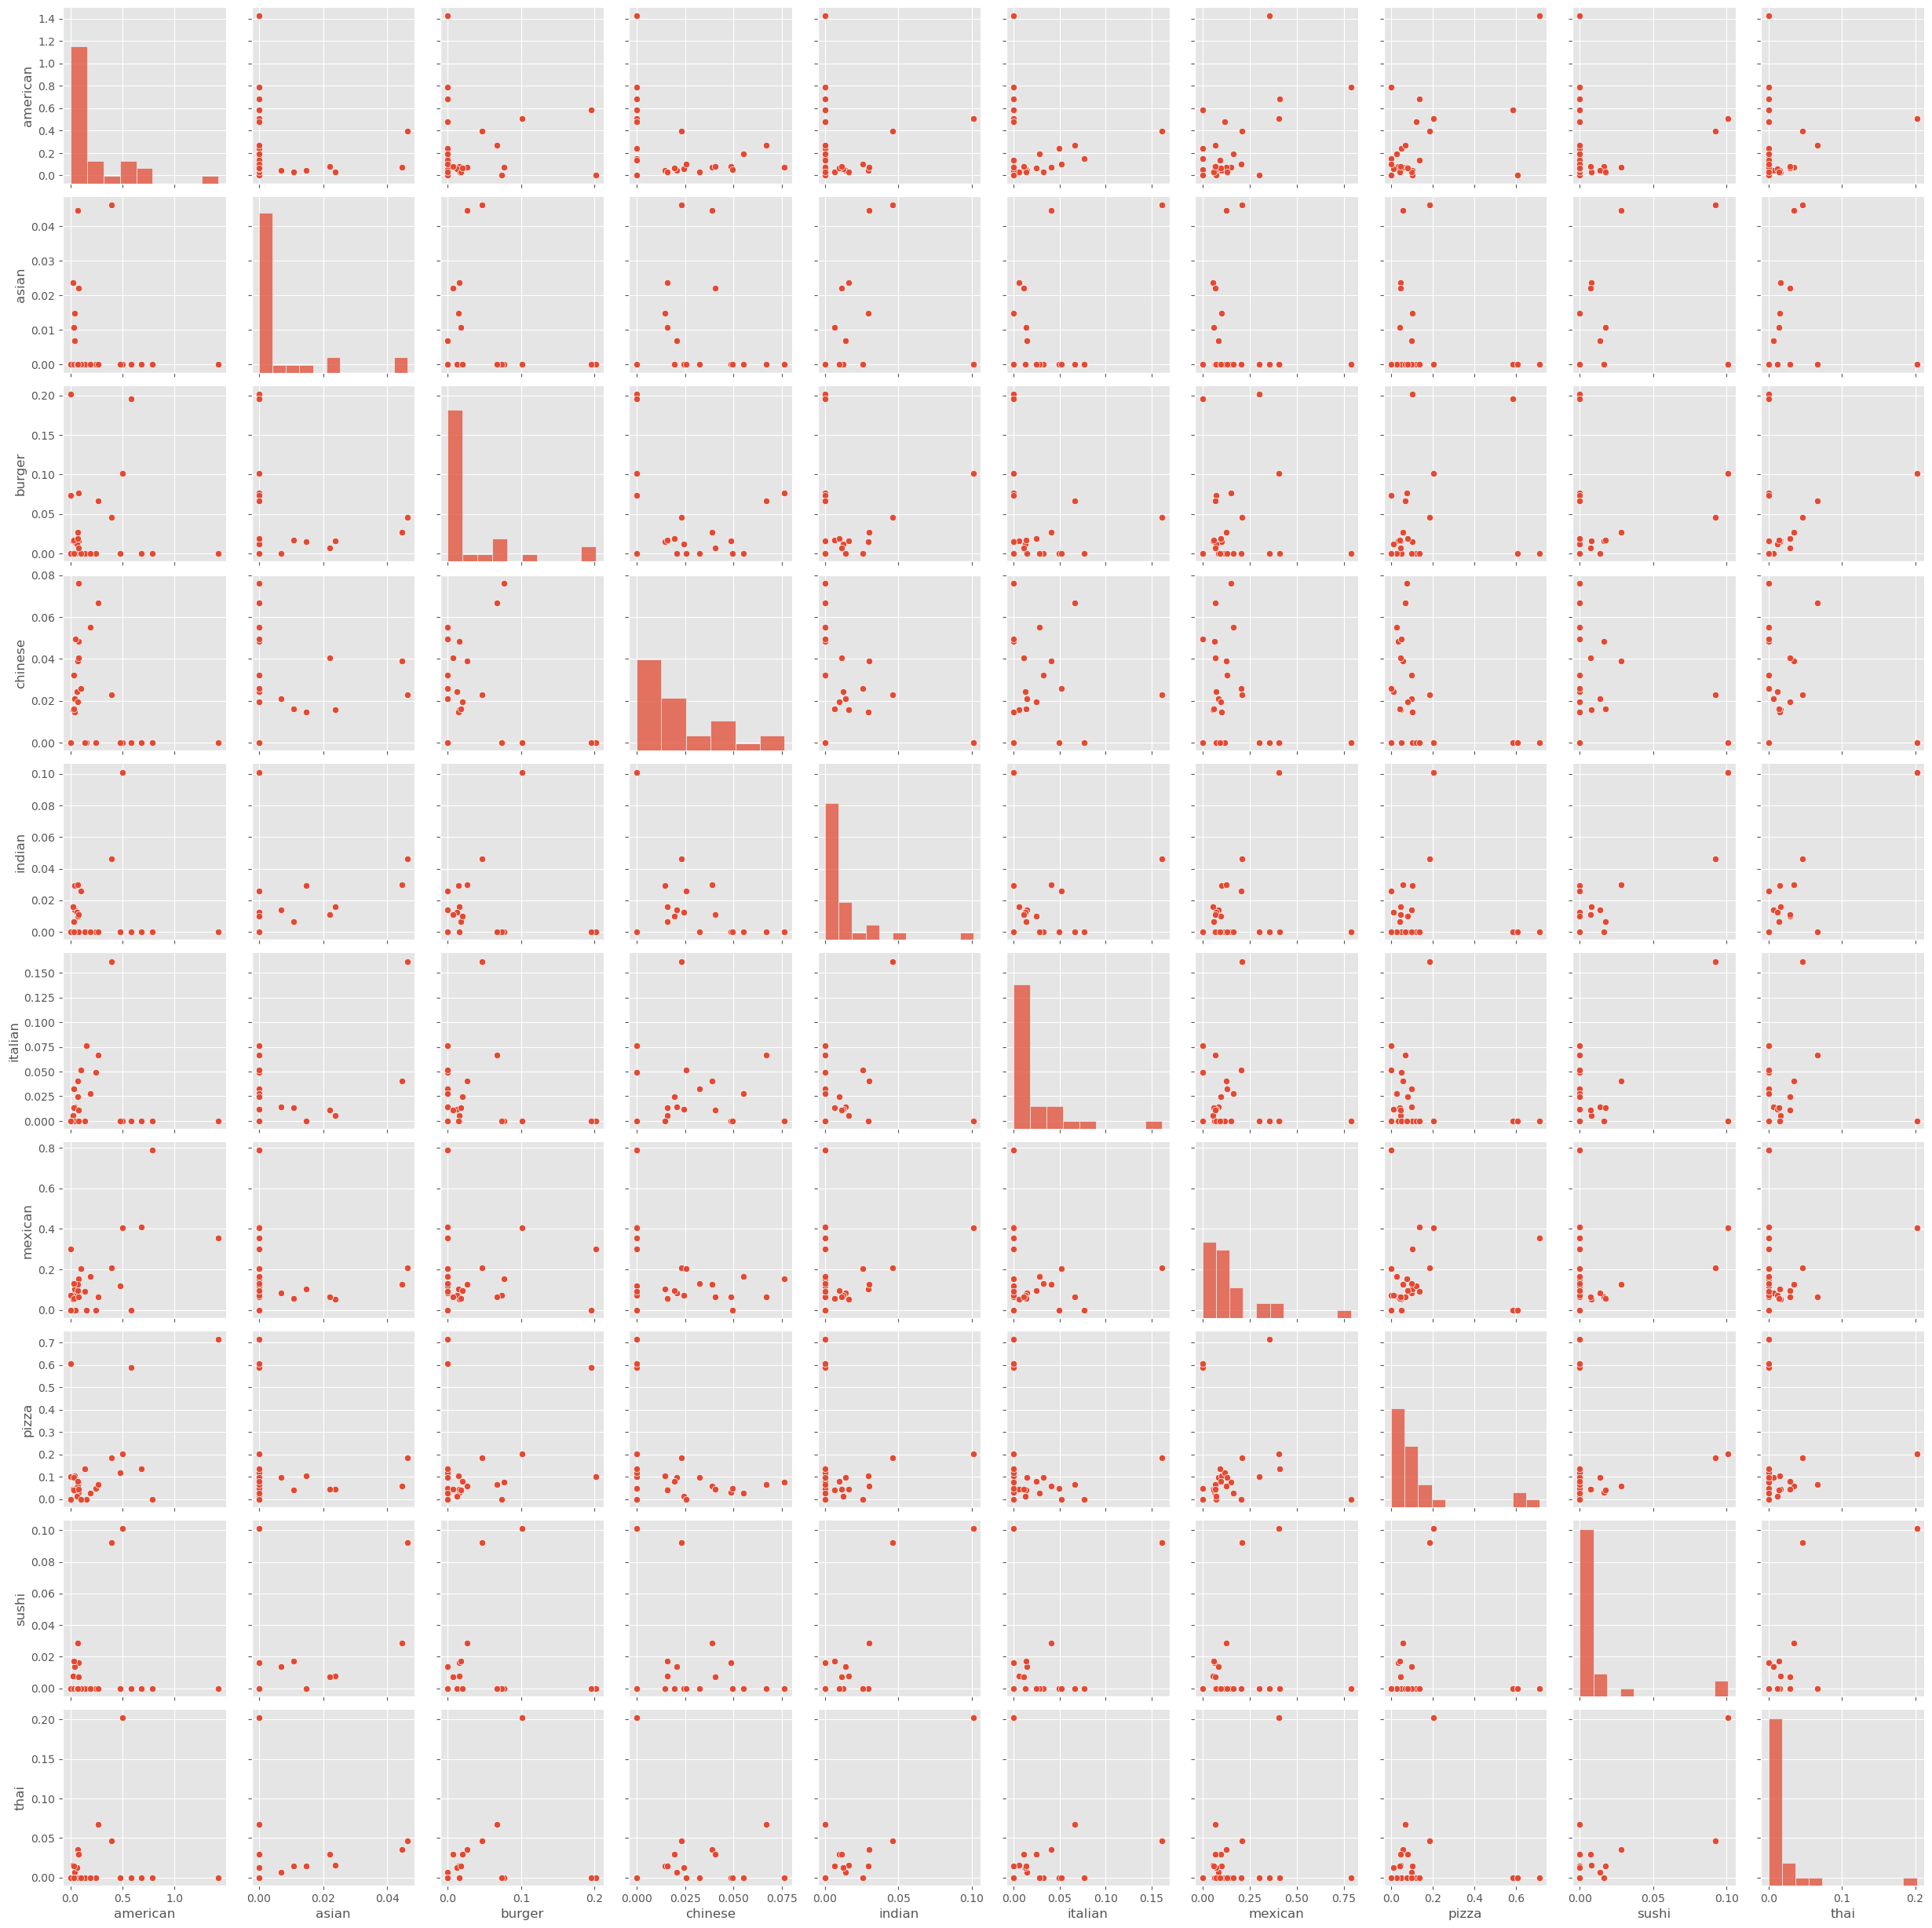

In [5]:
sns.pairplot(df_norm)
plt.show()

**Your description:** 
Mainstream cuisines (american, burger, mexican, italian) show positive correlations with each other, suggesting counties with higher restaurant density tend to have more of all these types. Specialty cuisines (asian, indian, sushi, thai) show weaker correlations, likely concentrated in more populous/diverse counties. Mexican, chinese, and pizza are more evenly distributed across counties compared to other cuisines, suggesting they are staple cuisines present even in smaller Utah counties. Most distributions are right-skewed, with most counties having very few restaurants of a given type, while one or two larger counties drive the high end.

### Task 1.3 - Cluster Heat Map

Generate a [cluster heat map](https://seaborn.pydata.org/generated/seaborn.clustermap.html) with a dendrogram using seaborn (see lecture). Be sure to standardize the dataset using the `standard_scale=1` parameter.

- How would you interpret this cluster map? 
- Describe any patterns you see.
- Is there anything in this data that surprises you? Do you trust it?

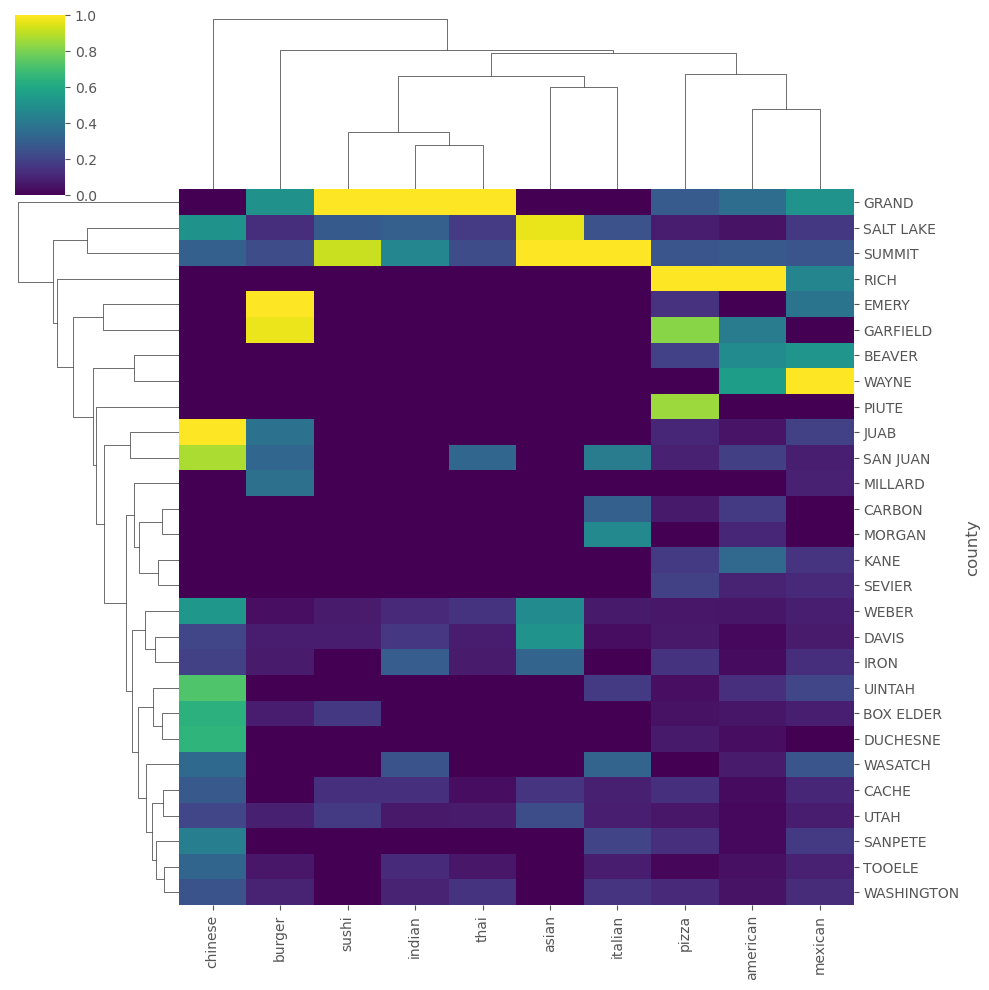

In [6]:
sns.clustermap(df_norm, standard_scale=1, cmap='viridis')
plt.show()

**Your Interpretation**: 

The clustermap reveals interesting groupings among Utah counties and cuisine types. On the county side, Tooele and Washington show similar cuisine patterns, as do Cache and Utah counties, and Carbon and Morgan, likely reflecting similar population sizes and demographics. Summit and Salt Lake stand out as the only counties with a wide distribution across all cuisine types, which makes sense given their higher populations and more diverse demographics. On the cuisine side, specialty cuisines (indian, thai, sushi, asian) cluster together and are essentially absent in most counties, appearing only in a handful of larger and more diverse urban areas. Italian also shows limited presence across many counties, behaving more like a specialty cuisine than a staple. Mainstream cuisines (american, burger, mexican, pizza, chinese) are more widely distributed. 

### Task 1.4 Visualize the data using PCA

Complete the following steps:
1. Scale the dataset using the *scale* function of the sklearn.preprocessing library. 
+ Calculate the principal components of the dataset. 
+  Store the principal components in a pandas dataframe. (Note - Index of this dataframe should be the names of the counties) 
+ Plot a scatterplot of PC1 and PC2. Using the matplotlib function *annotate*, use the county names as markers (instead of dots). From this scatterplot, can you tell approximately how many clusters our dataset shall have?
+ Print the explained variance ratio of the PCA. Plot the explained variance ratio of the PCA. After observing the explained variance ratio, how many dimensions would you reduce your data to? Why?

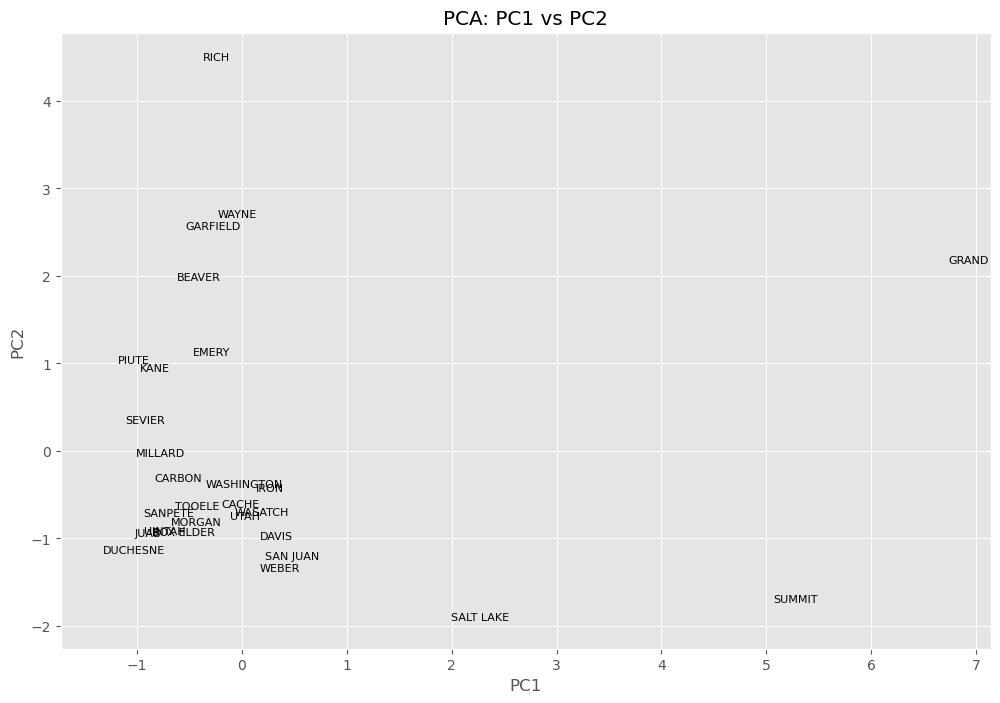

Explained variance ratio: [0.31436046 0.22879652 0.12160854 0.10928893 0.07519461 0.06735574
 0.05042935 0.01561581 0.01024055 0.00710949]


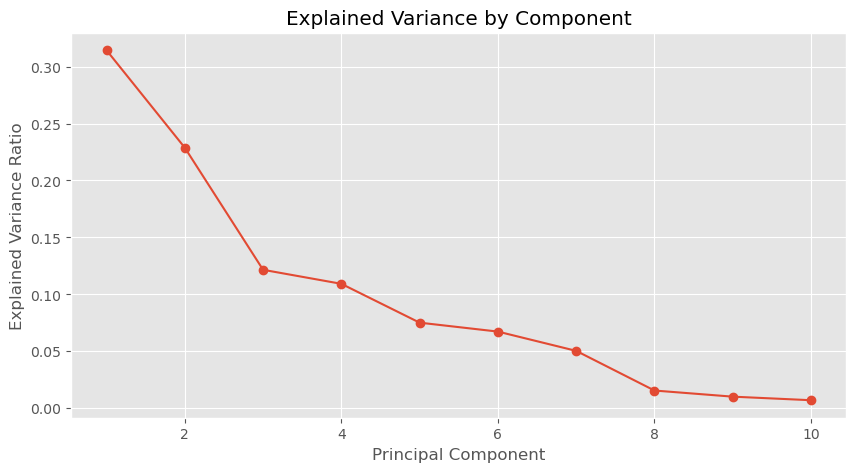

In [7]:
# Scale the data
df_scaled = scale(df_norm)

# Calculate PCA
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

# Store PCA results in a DataFrame with county names as index
df_pca = pd.DataFrame(data=pca_result, index=df_norm.index)

# Scatterplot of PC1 vs PC2 with county name labels
plt.figure(figsize=(12, 8))
plt.scatter(df_pca[0], df_pca[1], alpha=0)
for county in df_pca.index:
    plt.annotate(county, (df_pca[0][county], df_pca[1][county]), fontsize=8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2')
plt.show()

# Explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')
plt.show()

**Your description:**  

The data was scaled using sklearn's scale function and PCA was applied to reduce dimensionality. The first principal component captures 31% of the variance and the second captures 23%, together explaining 54% of the total variance. The explained variance line plot shows an elbow at PC3, where the curve begins to flatten out noticeably. The first 3 components collectively explain approximately 66% of the total variance, which is a reasonable tradeoff between dimensionality reduction and information retained, so I would reduce the data to 3 dimensions. The PCA scatterplot of PC1 vs PC2 reveals approximately 3 clusters. The majority of rural Utah counties form a dense group on the left side of the plot. Salt Lake and Summit counties are separated far to the right, reflecting their larger and more diverse populations. Grand county also stands out as an outlier, which is consistent with its tourism driven economy centered around Moab. Despite having a relatively small permanent population, the high volume of tourists likely supports a more diverse restaurant scene compared to other rural counties of similar size. Based on both the elbow in the explained variance line plot and the visual groupings in the PCA scatter plot, 3 clusters appears to be the most meaningful choice for this dataset.

### Task 1.5 k-means cluster analysis

1. Using k-means, cluster the counties into three clusters. **Use the scaled dataset**. Which counties belong to which clusters?
2. Vary k (between 2 and 20) and check if there could be a better value for k. If yes, what is that value? Also, describe how did you find that value?
3. Use the principal components to plot the clustering corresponding to the k you chose in the previous question. Again label each point using the county name and this time color the counties according to the clustering.


Cluster 0: ['BOX ELDER', 'DUCHESNE', 'EMERY', 'JUAB', 'SAN JUAN', 'UINTAH']
Cluster 1: ['GRAND', 'SUMMIT']
Cluster 2: ['BEAVER', 'CACHE', 'CARBON', 'DAVIS', 'GARFIELD', 'IRON', 'KANE', 'MILLARD', 'MORGAN', 'PIUTE', 'RICH', 'SALT LAKE', 'SANPETE', 'SEVIER', 'TOOELE', 'UTAH', 'WASATCH', 'WASHINGTON', 'WAYNE', 'WEBER']


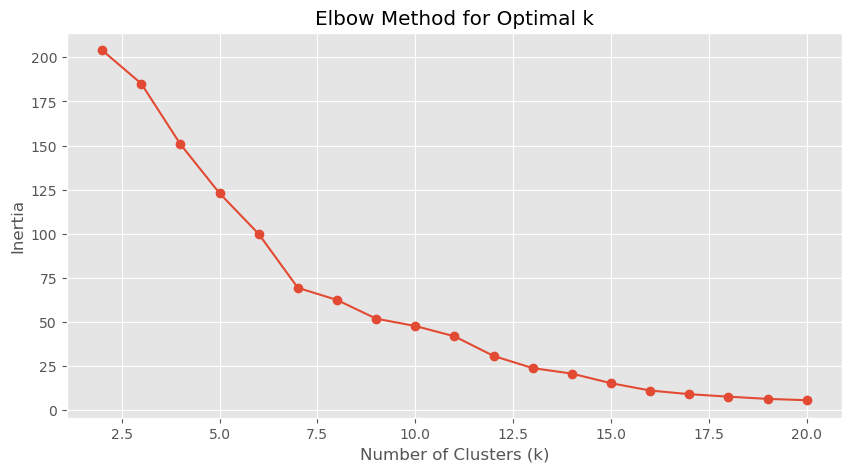

In [8]:
# K-means clustering with k=3 using scaled data
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_scaled)
labels = kmeans.labels_

# Let's print the which counties belong to which cluster
for cluster in range(3):
    counties = df_norm.index[labels == cluster].tolist()
    print(f"Cluster {cluster}: {counties}")

# Elbow method to determine optimal k
inertias = []
k_range = range(2, 21)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    inertias.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

**Interpretation for best K:**

Using the elbow method, k=7 was selected as the optimal number of clusters, as the inertia curve begins to flatten noticeably after this point. Some clusters contain only a single county, such as Summit, Rich, and Grand, which reflects their unique restaurant density profiles compared to other Utah counties. Grand and Summit stand out due to their tourism driven economies, while Rich county appears to have a distinct cuisine pattern despite its small size. The remaining clusters group counties with similar restaurant density profiles together.

Cluster 0: ['BOX ELDER', 'DUCHESNE', 'JUAB', 'SAN JUAN', 'UINTAH']
Cluster 1: ['SUMMIT']
Cluster 2: ['CACHE', 'CARBON', 'DAVIS', 'IRON', 'KANE', 'MILLARD', 'MORGAN', 'PIUTE', 'SALT LAKE', 'SANPETE', 'SEVIER', 'TOOELE', 'UTAH', 'WASATCH', 'WASHINGTON', 'WEBER']
Cluster 3: ['RICH']
Cluster 4: ['BEAVER', 'WAYNE']
Cluster 5: ['EMERY', 'GARFIELD']
Cluster 6: ['GRAND']


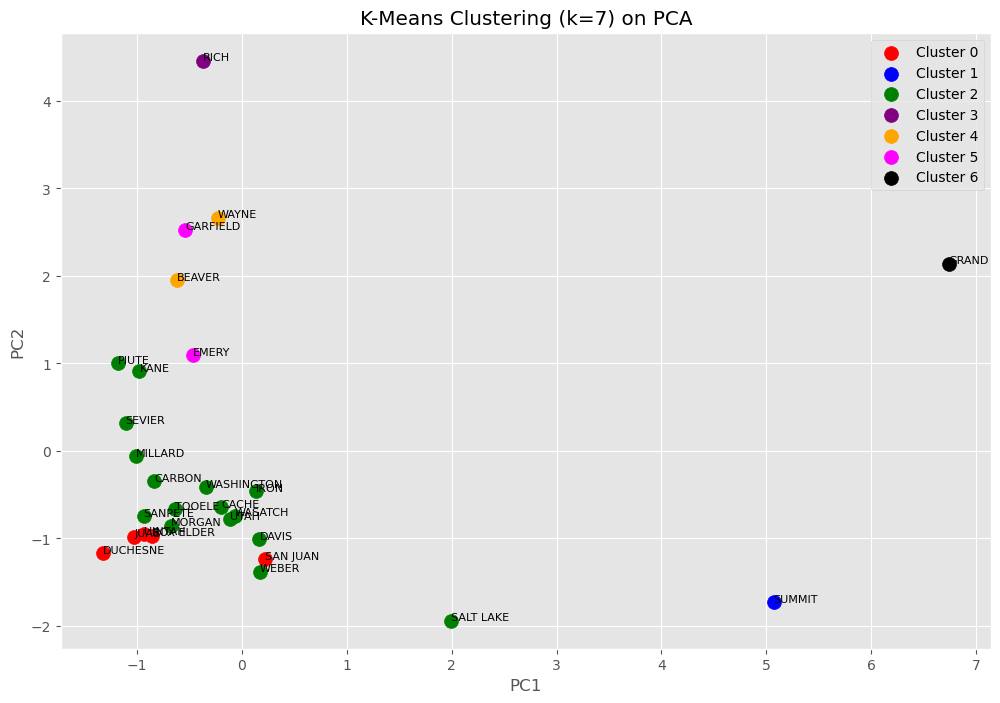

In [9]:
# Rerun k=7 explicitly
kmeans7 = KMeans(n_clusters=7, random_state=42)
kmeans7.fit(df_scaled)
labels7 = kmeans7.labels_

for cluster in range(7):
    counties = df_norm.index[labels7 == cluster].tolist()
    print(f"Cluster {cluster}: {counties}")

# Plot k=7 clusters on PCA scatter plot
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'purple', 'orange', 'magenta', 'black']

for cluster in range(7):
    cluster_counties = df_pca[labels7 == cluster]
    plt.scatter(cluster_counties[0], cluster_counties[1], 
                color=colors[cluster], label=f'Cluster {cluster}', s=100)

for county in df_pca.index:
    plt.annotate(county, (df_pca[0][county], df_pca[1][county]), fontsize=8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering (k=7) on PCA')
plt.legend()
plt.show()

**Interpretation for PCA and K-Means**: 

The PCA scatter plot with k=7 clusters reveals a clear separation between county groups. The majority of rural Utah counties form a large green cluster in the center and left of the plot. Some counties like San Juan and Salt Lake appear visually close to neighboring clusters in the 2D plot but are assigned to different clusters, which is expected since the clustering was performed in the full 10 dimensional space and the 2D PCA plot only captures 54% of the total variance. Summit and Grand counties are both isolated on the far right but belong to different clusters, reflecting their unique restaurant profiles. Rich county stands alone in the upper left, and Beaver and Wayne form a small distinct group in the upper middle area, while Garfield and Emery form a separate cluster despite appearing close to other groups in 2D. Overall the clustering results are reasonable given the limitations of 2D visualization.

### Task 1.6 Hierarchical cluster analysis

1.  Using hierarchical clustering with complete linkage and Euclidean distance, cluster the counties into the number of clusters you determined for k-means. Which counties belong to which clusters? 
2. Visualize your cluster results on top of the first two principle components, as before.
3. Do you get similar results as for k-means? Can you see trends between the counties?

Cluster 0: ['BOX ELDER', 'DUCHESNE', 'JUAB', 'SALT LAKE', 'SAN JUAN', 'UINTAH']
Cluster 1: ['EMERY', 'GARFIELD']
Cluster 2: ['CACHE', 'CARBON', 'DAVIS', 'IRON', 'KANE', 'MILLARD', 'MORGAN', 'PIUTE', 'SANPETE', 'SEVIER', 'TOOELE', 'UTAH', 'WASATCH', 'WASHINGTON', 'WEBER']
Cluster 3: ['SUMMIT']
Cluster 4: ['BEAVER', 'WAYNE']
Cluster 5: ['GRAND']
Cluster 6: ['RICH']


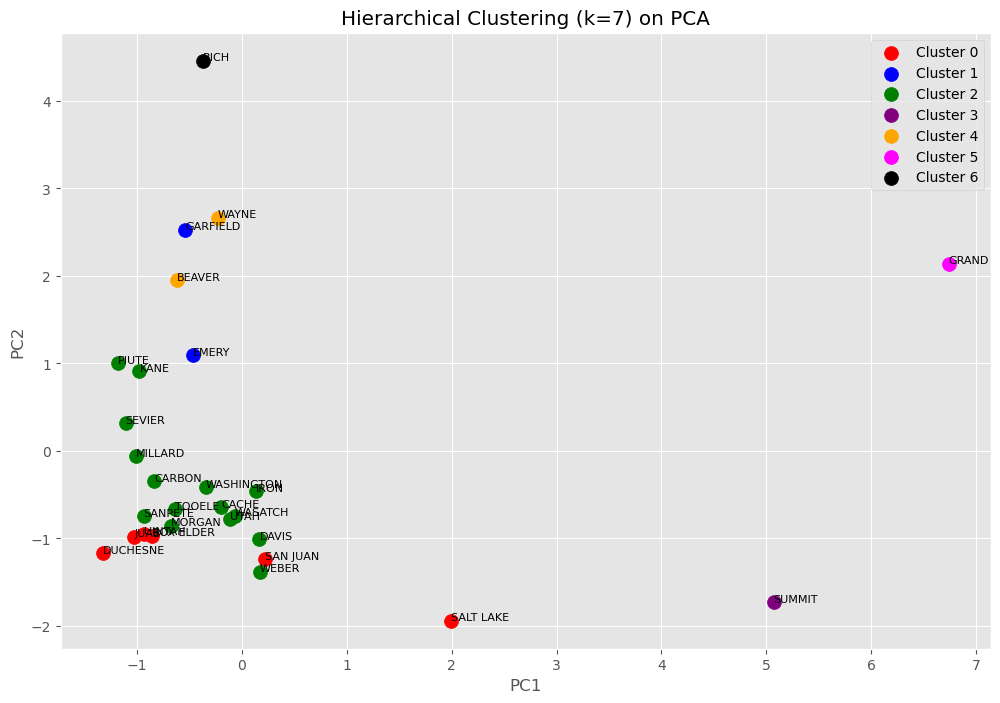

In [10]:
# Hierarchical Clustering with k=7
hc = AgglomerativeClustering(n_clusters=7, linkage='complete')
hc_labels = hc.fit_predict(df_scaled)

# Print which counties belong to which cluster
for cluster in range(7):
    counties = df_norm.index[hc_labels == cluster].tolist()
    print(f"Cluster {cluster}: {counties}")

# Plot on PCA scatter plot
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'purple', 'orange', 'magenta', 'black']

for cluster in range(7):
    cluster_counties = df_pca[hc_labels == cluster]
    plt.scatter(cluster_counties[0], cluster_counties[1],
                color=colors[cluster], label=f'Cluster {cluster}', s=100)

for county in df_pca.index:
    plt.annotate(county, (df_pca[0][county], df_pca[1][county]), fontsize=8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical Clustering (k=7) on PCA')
plt.legend()
plt.show()

**Interpretation:** 

Hierarchical clustering with complete linkage and k=7 produces results that are largely consistent with k-means. Both methods agree on isolating Grand, Summit, and Rich as individual clusters, and both group Beaver and Wayne together as well as Emery and Garfield together. The main difference is that Salt Lake is now placed with Box Elder, Duchesne, Juab, San Juan, and Uintah rather than the large rural cluster, which is a more intuitive result given its position on the PCA plot. Overall the two methods produce similar results, giving us more confidence that the clustering reflects genuine patterns in the data.

### Task 1.7 DBSCAN

1.  Using DBSCAN and experiment with different values for $\epsilon$ and min samples. Which counties belong to which clusters? 
2. Visualize your cluster results on top of the first two principle components, as before.
3. Do you get similar results as before? Is DBSCAN stable or very sensitive to changes in epsilon for this dataset?

eps=1.5, min_samples=1: 15 clusters, 0 noise points
eps=1.5, min_samples=2: 2 clusters, 13 noise points
eps=1.5, min_samples=3: 1 clusters, 15 noise points
eps=2.0, min_samples=1: 10 clusters, 0 noise points
eps=2.0, min_samples=2: 1 clusters, 9 noise points
eps=2.0, min_samples=3: 1 clusters, 9 noise points
eps=2.5, min_samples=1: 8 clusters, 0 noise points
eps=2.5, min_samples=2: 1 clusters, 7 noise points
eps=2.5, min_samples=3: 1 clusters, 7 noise points
Noise: ['EMERY', 'GARFIELD', 'GRAND', 'PIUTE', 'RICH', 'SALT LAKE', 'SAN JUAN', 'SUMMIT', 'WAYNE']
Cluster 0: ['BEAVER', 'BOX ELDER', 'CACHE', 'CARBON', 'DAVIS', 'DUCHESNE', 'IRON', 'JUAB', 'KANE', 'MILLARD', 'MORGAN', 'SANPETE', 'SEVIER', 'TOOELE', 'UINTAH', 'UTAH', 'WASATCH', 'WASHINGTON', 'WEBER']


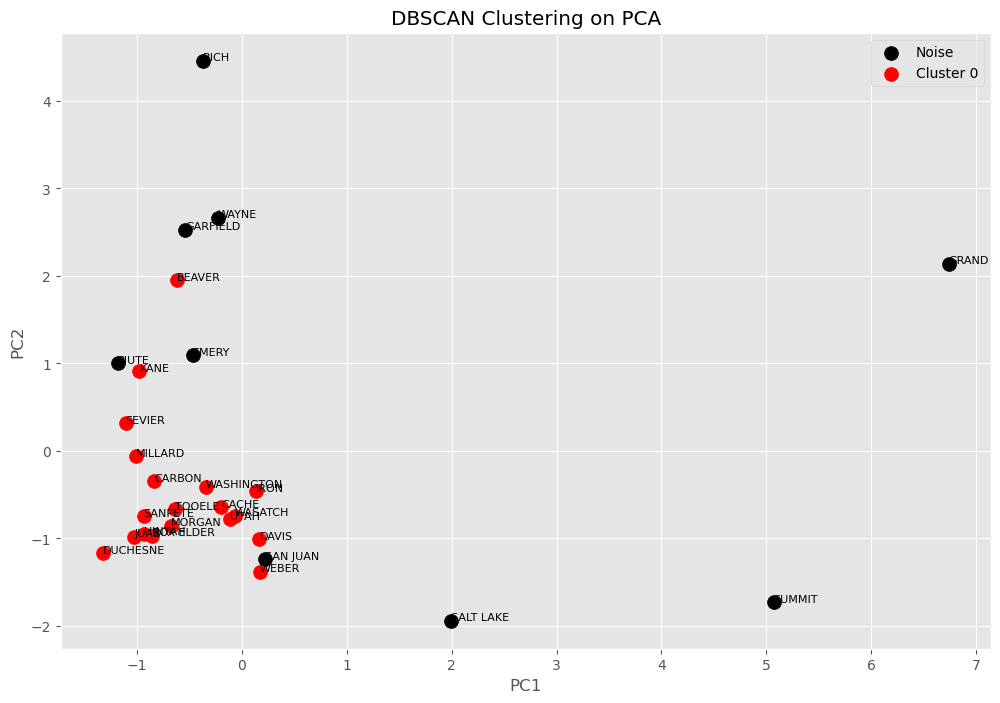

In [11]:
# Experiment with different epsilon and min_samples values
for eps in [1.5, 2.0, 2.5]:
    for min_s in [1, 2, 3]:
        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        db_labels = dbscan.fit_predict(df_scaled)
        n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        n_noise = list(db_labels).count(-1)
        print(f"eps={eps}, min_samples={min_s}: {n_clusters} clusters, {n_noise} noise points")

# Final choice: eps=2.0, min_samples=2
dbscan = DBSCAN(eps=2.0, min_samples=2)
db_labels = dbscan.fit_predict(df_scaled)

for cluster in sorted(set(db_labels)):
    counties = df_norm.index[db_labels == cluster].tolist()
    if cluster == -1:
        print(f"Noise: {counties}")
    else:
        print(f"Cluster {cluster}: {counties}")

# Plot on PCA scatter plot
plt.figure(figsize=(12, 8))
unique_labels = sorted(set(db_labels))
colors = ['black', 'red', 'blue', 'green', 'purple', 'orange', 'magenta']

for i, cluster in enumerate(unique_labels):
    cluster_counties = df_pca[db_labels == cluster]
    label = "Noise" if cluster == -1 else f"Cluster {cluster}"
    plt.scatter(cluster_counties[0], cluster_counties[1],
                color=colors[i], label=label, s=100)

for county in df_pca.index:
    plt.annotate(county, (df_pca[0][county], df_pca[1][county]), fontsize=8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clustering on PCA')
plt.legend()
plt.show()

**Your Interpretation**: 

After experimenting with different epsilon and min_samples values, eps=2.0 and min_samples=2 was selected as the final choice. DBSCAN identified one cluster containing 19 rural counties and labeled 9 counties as noise, including Grand, Summit, Salt Lake, Rich, Emery, Garfield, Piute, San Juan and Wayne. These noise counties are visible as black dots scattered around the edges of the PCA plot, while the red cluster forms the dense group in the center and left. Compared to k-means and hierarchical clustering, DBSCAN produces less informative results for this dataset since it cannot distinguish between the different outlier counties and simply labels them all as noise. DBSCAN is also very sensitive to parameter changes on this dataset. For example, changing min_samples from 1 to 2 at eps=1.5 jumps from 15 clusters to 2 clusters, and increasing eps from 1.5 to 2.0 with min_samples=2 drops from 2 clusters to 1 cluster. This sensitivity suggests that the data does not have the uniform density that DBSCAN works best with, making k-means a more suitable algorithm for this particular dataset.

# 2. Regular Expressions 

Write regular expressions for the following examples that matches the data of the given format and any other reasonable variations thereof. E.g., your regex shouldn't be specific to one URL or one phone number, but should work for all examples of the same format.

**Task 2.1.** Writes a regular expression that extracts the urls out of this string, specifically the part after the `https://`

In [12]:
text = """To find out more about the math department, go to: https://www.math.utah.edu/
Alternatively, to find out more about computing, go to: https://www.cs.utah.edu/ 
You may also find out about data science at: https://datasciencecourse.net/2024/"""
print(text)

To find out more about the math department, go to: https://www.math.utah.edu/
Alternatively, to find out more about computing, go to: https://www.cs.utah.edu/ 
You may also find out about data science at: https://datasciencecourse.net/2024/


In [13]:
urls = re.findall(r'https://(\S+)', text)
print(urls)

['www.math.utah.edu/', 'www.cs.utah.edu/', 'datasciencecourse.net/2024/']


**Task 2.2.** Write a regular expression that extracts all phone numbers and fax numbers from this text: 

In [14]:
text = """You can reach me at 415-273-9164, or my office at (212) 555-2368 or (212) 606-0842.\ 
Send me a fax at 857 555 0164 or 4791395522. We finally made the sale for all 196 giraffes.\
They purchase order is 376 152."""

In [15]:
phones = re.findall(r'\(?\d{3}\)?[\s\-\.]?\d{3}[\s\-\.]?\d{4}', text)
print(phones)

['415-273-9164', '(212) 555-2368', '(212) 606-0842', '857 555 0164', '4791395522']


**Task 2.3.** Write a regular expression that extracts the entirety of all closing html tags (e.g., including the `<` and `>`) from `html`.

In [16]:
html = """<center>This is <b>important</b> and <u>very</u><i>timely</i><br />.\
</center> Was this <span> what you meant?</span>.<video>intro</video>."""

In [17]:
closing_tags = re.findall(r'</\w+>', html)
print(closing_tags)

['</b>', '</u>', '</i>', '</center>', '</span>', '</video>']


**Task 2.4.** Write a regular expression that extracts all the names of people, real or fictitious, from the following text. 

In [18]:
text = """Set in Hollywood, the comedy drama stars Will Arnett, Amy Sedaris, Alison Brie, \
Paul F. Tompkins, and  Aaron Paul."""

In [19]:
names = re.findall(r'[A-Z][a-z]+(?:\s[A-Z]\.)?(?:\s[A-Z][a-z]+)+', text)
print(names)

['Will Arnett', 'Amy Sedaris', 'Alison Brie', 'Paul F. Tompkins', 'Aaron Paul']


**Task 2.5.** Write a regular expression that extracts all the image URLs from the html.

In [20]:
text = """ 
<img class="dataimage" src="https://datasciencecourse.net/2024/assets/i/teaser.png">
<img width="140" height="140" src="https://www.math.utah.edu/_resources/images/web-buttons/MajorsMinors.png">
<img class="srcimage" src="https://csszengarden.com/211/title01.jpg">
"""

In [21]:
image_urls = re.findall(r'src="(https://[^"]+)"', text)
print(image_urls)

['https://datasciencecourse.net/2024/assets/i/teaser.png', 'https://www.math.utah.edu/_resources/images/web-buttons/MajorsMinors.png', 'https://csszengarden.com/211/title01.jpg']


## 3. NLP: Classifying Newsgroups Articles

Newsgroups were the social media of the 80s and 90s. Newsgroups are open discussion forums structured into hierarchies. For example, the following newsgroups cover topics as diverse as atheism, computer graphics, and classified ads.  

```
alt.atheism
comp.graphics
comp.os.ms-windows.misc
comp.sys.ibm.pc.hardware
comp.sys.mac.hardware
comp.windows.x
misc.forsale
```

We will be combining machine learning and natural language processing to classify the news articles into these groups. We expect, for example, that the text for a classified ad in `misc.forsale` is different from text in `alt.atheism`. 

We will use the 20 Newsgroups corpus from scikit-learn. The 20 newsgroups dataset comprises around 18,000 newsgroups posts on 20 topics. The general steps we follow are:
1. Load the corpus    
2. Do preprocessing: removal of stopwords, stemming, etc.
3. Vectorize the text
4. Split into training and test sets
5. Train our classifier

Refer to documentation on the [20 newsgroups dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html) to learn about the dataset and find out how to download it.
We recommended you use the `subset='all'` parameter to load all the data at once, instead of `subset='train'` and `subset='test'` separately.

### Task 3.1 Load the dataset.

1. Print the exact number of news articles in the corpus.
2. Print all 20 categories the news articles belong to.

In [22]:
# Load the 20 newsgroups dataset
newsgroups = fetch_20newsgroups(subset='all')

print(f"Number of articles: {len(newsgroups.data)}")
print(f"\nCategories:")
for category in newsgroups.target_names:
    print(category)

Number of articles: 18846

Categories:
alt.atheism
comp.graphics
comp.os.ms-windows.misc
comp.sys.ibm.pc.hardware
comp.sys.mac.hardware
comp.windows.x
misc.forsale
rec.autos
rec.motorcycles
rec.sport.baseball
rec.sport.hockey
sci.crypt
sci.electronics
sci.med
sci.space
soc.religion.christian
talk.politics.guns
talk.politics.mideast
talk.politics.misc
talk.religion.misc


### Task 3.2 Classification

Vectorize the data using vectorizers from sklearn. Using these vectors as features and the article category from corpus as labels, train a NaiveBayes classifier to classify the data.

#### Vectorizers

Vectorizes help us to transform text data into features we can use in machine learning. We did the vectorization manually in class, here you will use pre-build vectorizers. 

You should use CountVectorizer and TfidfVectorizer vectorizers from sklearn to vectorize your data. Please refer to documentation on both to learn how to use them.
+ http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html
+ http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

Compare the performance of a Naive Bayes classifier (see details below) using both vectorizers. You are encouraged to experiment with different parameters like max_df, min_df, etc. See docs for the meanings.

#### Naive Bayes
**Resources**
1. https://en.wikipedia.org/wiki/Naive_Bayes_classifier
2. https://www.geeksforgeeks.org/naive-bayes-classifiers
3. http://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

We will be using Multinomial Naive Bayes from sklearn. Refer to documentation above for how to import the classifier. Then it can be used like any other classifier by using fit and predict functions provided on it.
e.g:

```
clf = MulitnomialNB(alpha = 1)
clf.fit(X_train, Y_train)
y_pred = clf.predict(X_test)
```

Alpha is also known as the smoothing factor and ranges from 0 (no smoothing) to 1 (Laplace Smoothing). You can experiment with different values to see if you get better results. 

In [25]:
# Get data and labels
X = newsgroups.data
y = newsgroups.target

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CountVectorizer
count_vec = CountVectorizer()
X_train_count = count_vec.fit_transform(X_train)
X_test_count = count_vec.transform(X_test)

clf_count = MultinomialNB(alpha=1)
clf_count.fit(X_train_count, y_train)
y_pred_count = clf_count.predict(X_test_count)
print(f"CountVectorizer accuracy: {accuracy_score(y_test, y_pred_count):.4f}")

# TfidfVectorizer
tfidf_vec = TfidfVectorizer()
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

clf_tfidf = MultinomialNB(alpha=1)
clf_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
print(f"TfidfVectorizer accuracy: {accuracy_score(y_test, y_pred_tfidf):.4f}")

CountVectorizer accuracy: 0.8512
TfidfVectorizer accuracy: 0.8475


### Task 3.3 Removing Stopwords

Now we'll remove the stopwords to improve our data vectors. TfidfVectorizer and CountVectorizer both can take an argument called stop_words. The words passed to this argument are considered as stopwords and are not vectorized. Then evaluate the new vectors using Multinomial Naive Bayes.

Answer the following questions:
1. What accuracy were you able to achieve? 
2. What was the influence of the different vectorizers and the stopword removal? 

In [26]:
# CountVectorizer with stopwords
count_vec_sw = CountVectorizer(stop_words='english')
X_train_count_sw = count_vec_sw.fit_transform(X_train)
X_test_count_sw = count_vec_sw.transform(X_test)

clf_count_sw = MultinomialNB(alpha=1)
clf_count_sw.fit(X_train_count_sw, y_train)
y_pred_count_sw = clf_count_sw.predict(X_test_count_sw)
print(f"CountVectorizer with stopwords accuracy: {accuracy_score(y_test, y_pred_count_sw):.4f}")

# TfidfVectorizer with stopwords
tfidf_vec_sw = TfidfVectorizer(stop_words='english')
X_train_tfidf_sw = tfidf_vec_sw.fit_transform(X_train)
X_test_tfidf_sw = tfidf_vec_sw.transform(X_test)

clf_tfidf_sw = MultinomialNB(alpha=1)
clf_tfidf_sw.fit(X_train_tfidf_sw, y_train)
y_pred_tfidf_sw = clf_tfidf_sw.predict(X_test_tfidf_sw)
print(f"TfidfVectorizer with stopwords accuracy: {accuracy_score(y_test, y_pred_tfidf_sw):.4f}")

CountVectorizer with stopwords accuracy: 0.8745
TfidfVectorizer with stopwords accuracy: 0.8785


**Interpretation:** 

Using CountVectorizer without stopwords achieved 85.12% accuracy and TfidfVectorizer achieved 84.75%. After removing stopwords, CountVectorizer improved to 87.45% and TfidfVectorizer improved to 87.85%. Removing stopwords consistently improved performance for both vectorizers because common words like 'the', 'is', and 'and' add noise without carrying meaningful information for classification. TfidfVectorizer with stopword removal performed best overall, as it both downweights common words across documents and removes stopwords entirely.